# Phase 2.5 — Temperature vs Operating Conditions

The core premise of Normal Behavior Modeling (NBM) is that **component temperatures are predictable from operating conditions**. Wind speed drives mechanical load, which drives power output and heat generation. Ambient temperature sets the baseline heat-sink capacity. RPM and pitch angle modulate rotational friction and aerodynamic loading.

If we can show strong, consistent relationships between operating conditions and temperatures, then a model trained on healthy data can learn "what temperature *should* be." When actual temperature deviates from that prediction, something is physically wrong — that residual becomes our anomaly signal.

In [1]:
import sys
from pathlib import Path

# Add project root to sys.path so we can import from src/
PROJECT_ROOT = Path("D:/Personal Projects/Enbridge Case Compettion")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.nonparametric.smoothers_lowess import lowess
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

from src.data.load_data import load_farm_training_data
from src.features.thermal_config import get_sensors, get_all_thermal_sensors, THERMAL_SUBSYSTEMS
from src.features.operating_conditions import (
    get_operating_features,
    FEATURE_DESCRIPTIONS,
    FEATURE_CATEGORIES,
)

# Plotting defaults
sns.set_style("whitegrid")
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.size": 9,
})

FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------------------------
# Friendly sensor labels (for axis labels instead of raw column names)
# ---------------------------------------------------------------------------
SENSOR_LABELS = {
    # Farm A
    "sensor_12_avg": "Gearbox Oil Temp",
    "sensor_11_avg": "Gearbox Bearing Temp",
    "sensor_13_avg": "Generator Bearing DE Temp",
    "sensor_14_avg": "Generator Bearing NDE Temp",
    "sensor_15_avg": "Generator Winding U Temp",
    "sensor_16_avg": "Generator Winding V Temp",
    "sensor_17_avg": "Generator Winding W Temp",
    "sensor_38_avg": "Transformer Phase 1 Temp",
    "sensor_39_avg": "Transformer Phase 2 Temp",
    "sensor_40_avg": "Transformer Phase 3 Temp",
    "sensor_41_avg": "Hydraulic Oil Temp",
    "sensor_8_avg":  "Cooling Liquid Temp",
    "sensor_0_avg":  "Ambient Temp",
    # Farm B
    "sensor_34_avg": "Gearbox Oil Sump Temp (B)",
    "sensor_35_avg": "Gearbox HS Bearing Temp (B)",
    "sensor_32_avg": "Generator Bearing 1 Temp (B)",
    "sensor_33_avg": "Generator Bearing 2 Temp (B)",
    # Farm C
    "sensor_151_avg": "Gearbox Oil Sump Temp (C)",
    "sensor_152_avg": "Gearbox Bearing Temp (C)",
    "sensor_18_avg":  "Generator Bearing Temp (C)",
}

# Primary sensors for cross-farm gearbox comparison
GEARBOX_OIL_SENSOR = {
    "A": "sensor_12_avg",
    "B": "sensor_34_avg",
    "C": "sensor_151_avg",
}

POWER_COL = {
    "A": "power_29_avg",
    "B": "power_62_avg",
    "C": "power_6_avg",
}

WIND_COL = {
    "A": "wind_speed_3_avg",
    "B": "wind_speed_61_avg",
    "C": "wind_speed_235_avg",
}

AMBIENT_COL = {
    "A": "sensor_0_avg",
    "B": "sensor_8_avg",
    "C": "sensor_7_avg",
}

# ---------------------------------------------------------------------------
# Load training data for all three farms
# ---------------------------------------------------------------------------
print("Loading training data...")
df_a = load_farm_training_data("A")
df_b = load_farm_training_data("B")
df_c = load_farm_training_data("C")

print(f"Farm A: {df_a.shape[0]:,} rows, {df_a.shape[1]} cols")
print(f"Farm B: {df_b.shape[0]:,} rows, {df_b.shape[1]} cols")
print(f"Farm C: {df_c.shape[0]:,} rows, {df_c.shape[1]} cols")
print(f"\nFigures will be saved to: {FIGURES_DIR}")

Loading training data...


Farm A: 464,694 rows, 86 cols
Farm B: 418,792 rows, 257 cols
Farm C: 1,439,077 rows, 957 cols

Figures will be saved to: D:\Personal Projects\Enbridge Case Compettion\outputs\figures


## Gearbox Oil Temperature vs Wind Speed & Power

The gearbox is the most mechanically stressed component in a wind turbine drivetrain. Oil temperature rises with load (driven by wind speed and power output). We expect a clear nonlinear relationship: temperature rises steeply through the cubic power region, then flattens near rated power as thermal equilibrium is reached.

**Color encoding a third variable** lets us see the 3-way interaction in a 2D scatter — e.g., at the same wind speed, higher power should correspond to higher gearbox temp.

Saved: temp_vs_ops_gearbox_oil_farm_a.png


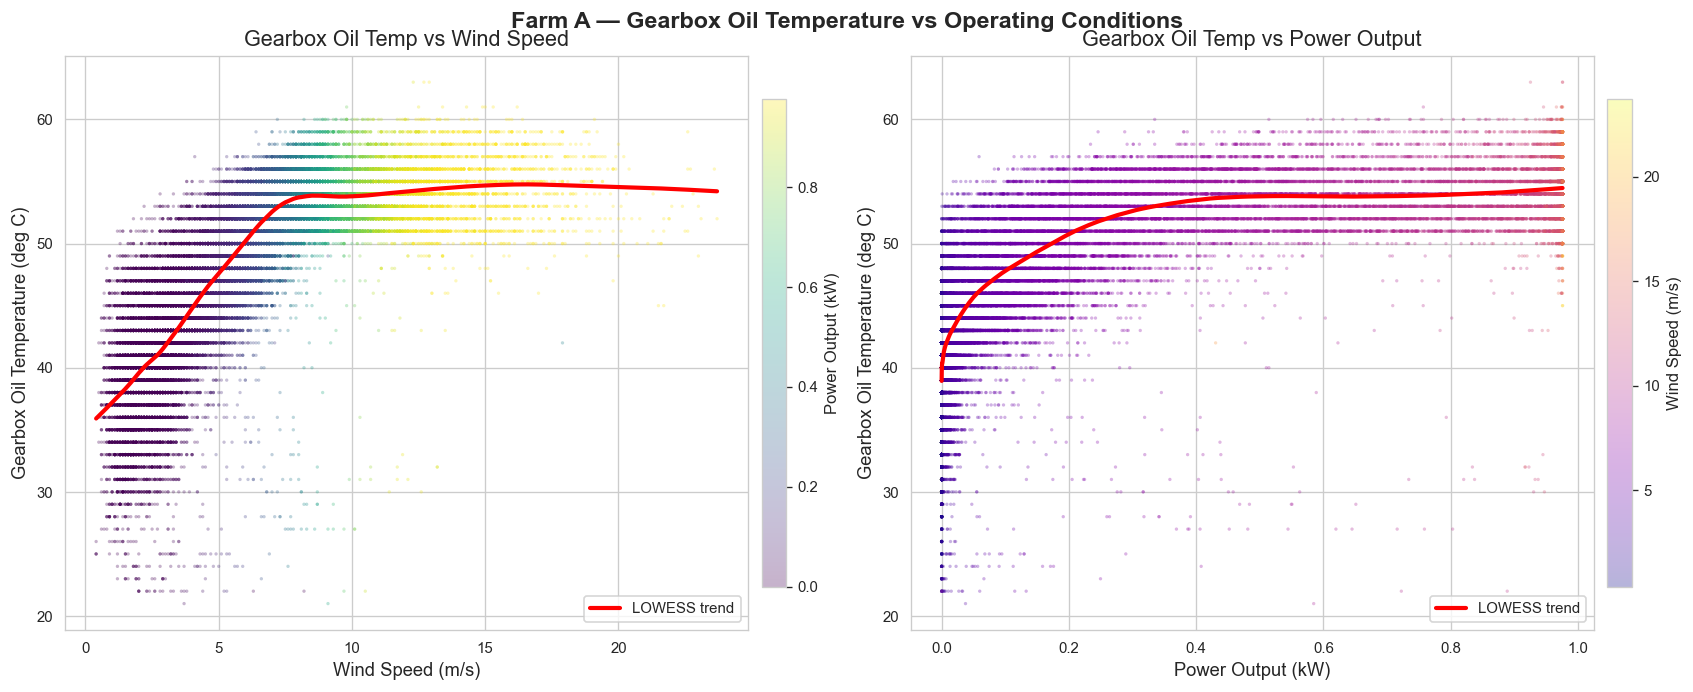

In [2]:
# --- Gearbox Oil Temp vs Wind Speed & Power (Farm A) ---
SAMPLE_N = 30_000

temp_col = "sensor_12_avg"
ws_col = WIND_COL["A"]
pw_col = POWER_COL["A"]

# Build clean subset and sample
plot_df = df_a[[ws_col, pw_col, temp_col]].dropna()
if len(plot_df) > SAMPLE_N:
    plot_df = plot_df.sample(n=SAMPLE_N, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), constrained_layout=True)

# --- Left panel: Gearbox Oil Temp vs Wind Speed, colored by Power ---
sc1 = axes[0].scatter(
    plot_df[ws_col], plot_df[temp_col],
    c=plot_df[pw_col], cmap="viridis", s=4, alpha=0.3,
    edgecolors="none", rasterized=True,
)
cb1 = fig.colorbar(sc1, ax=axes[0], shrink=0.85, pad=0.02)
cb1.set_label("Power Output (kW)", fontsize=10)

# LOWESS trend line
sorted_idx = plot_df[ws_col].argsort()
ws_sorted = plot_df[ws_col].values[sorted_idx]
temp_sorted = plot_df[temp_col].values[sorted_idx]
lw = lowess(temp_sorted, ws_sorted, frac=0.15)
axes[0].plot(lw[:, 0], lw[:, 1], color="red", linewidth=2.5, label="LOWESS trend")

axes[0].set_xlabel("Wind Speed (m/s)")
axes[0].set_ylabel("Gearbox Oil Temperature (deg C)")
axes[0].set_title("Gearbox Oil Temp vs Wind Speed")
axes[0].legend(loc="lower right", fontsize=9)

# --- Right panel: Gearbox Oil Temp vs Power, colored by Wind Speed ---
sc2 = axes[1].scatter(
    plot_df[pw_col], plot_df[temp_col],
    c=plot_df[ws_col], cmap="plasma", s=4, alpha=0.3,
    edgecolors="none", rasterized=True,
)
cb2 = fig.colorbar(sc2, ax=axes[1], shrink=0.85, pad=0.02)
cb2.set_label("Wind Speed (m/s)", fontsize=10)

# LOWESS trend line
sorted_idx2 = plot_df[pw_col].argsort()
pw_sorted = plot_df[pw_col].values[sorted_idx2]
temp_sorted2 = plot_df[temp_col].values[sorted_idx2]
lw2 = lowess(temp_sorted2, pw_sorted, frac=0.15)
axes[1].plot(lw2[:, 0], lw2[:, 1], color="red", linewidth=2.5, label="LOWESS trend")

axes[1].set_xlabel("Power Output (kW)")
axes[1].set_ylabel("Gearbox Oil Temperature (deg C)")
axes[1].set_title("Gearbox Oil Temp vs Power Output")
axes[1].legend(loc="lower right", fontsize=9)

fig.suptitle("Farm A — Gearbox Oil Temperature vs Operating Conditions",
             fontsize=14, fontweight="bold", y=1.02)

fig.savefig(FIGURES_DIR / "temp_vs_ops_gearbox_oil_farm_a.png", bbox_inches="tight", dpi=150)
print(f"Saved: temp_vs_ops_gearbox_oil_farm_a.png")
plt.show()

## Generator Bearing Temperature vs Operating Conditions

Generator bearings are the second most critical subsystem. They experience both rotational friction (RPM-dependent) and electrical heating from generator load. We expect a similar pattern to the gearbox, but potentially a tighter relationship since generator bearing temperature responds more directly to electrical output.

Saved: temp_vs_ops_gen_bearing_farm_a.png


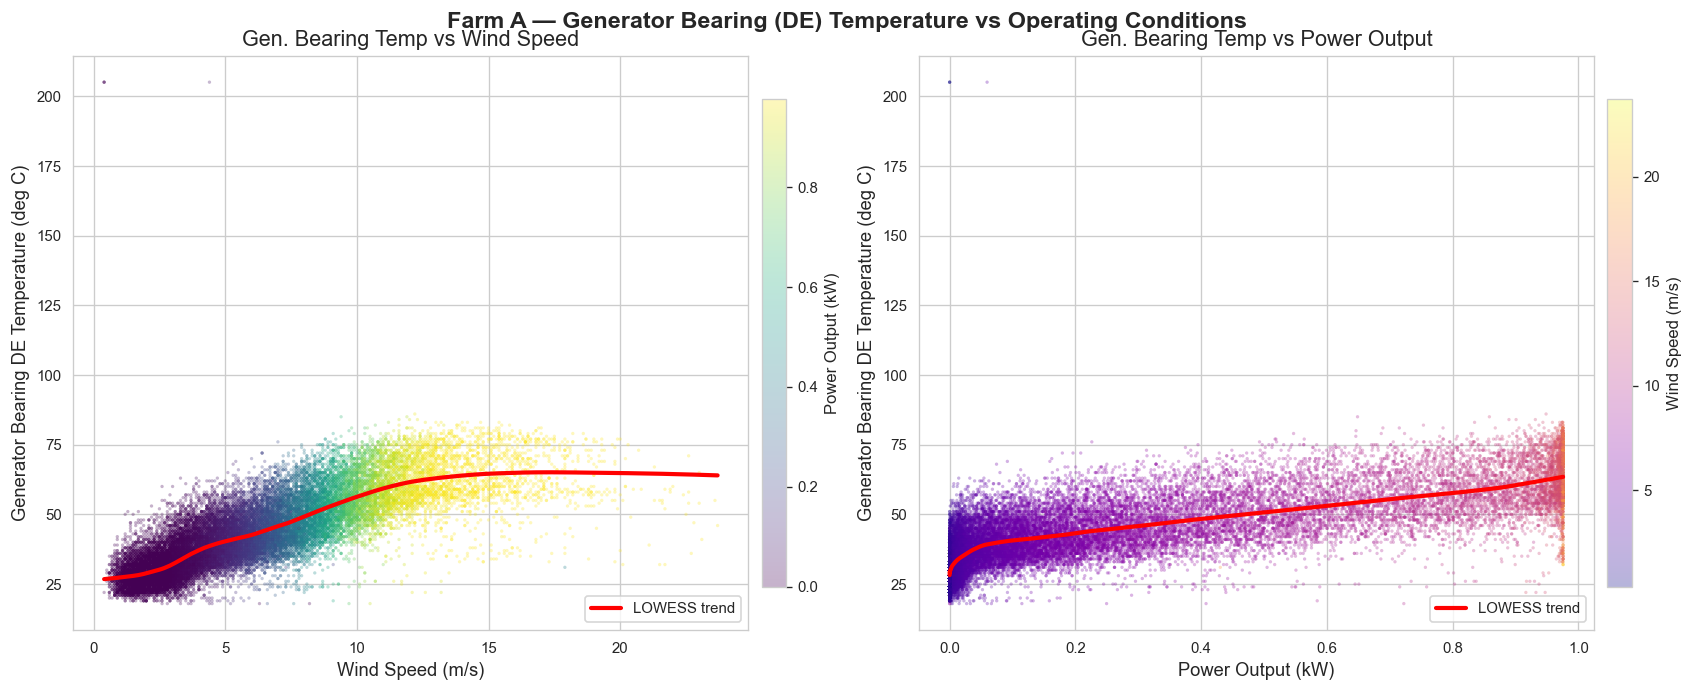

In [3]:
# --- Generator Bearing DE Temp vs Wind Speed & Power (Farm A) ---
temp_col = "sensor_13_avg"
ws_col = WIND_COL["A"]
pw_col = POWER_COL["A"]

plot_df = df_a[[ws_col, pw_col, temp_col]].dropna()
if len(plot_df) > SAMPLE_N:
    plot_df = plot_df.sample(n=SAMPLE_N, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), constrained_layout=True)

# --- Left: vs Wind Speed, colored by Power ---
sc1 = axes[0].scatter(
    plot_df[ws_col], plot_df[temp_col],
    c=plot_df[pw_col], cmap="viridis", s=4, alpha=0.3,
    edgecolors="none", rasterized=True,
)
cb1 = fig.colorbar(sc1, ax=axes[0], shrink=0.85, pad=0.02)
cb1.set_label("Power Output (kW)", fontsize=10)

sorted_idx = plot_df[ws_col].argsort()
lw = lowess(plot_df[temp_col].values[sorted_idx], plot_df[ws_col].values[sorted_idx], frac=0.15)
axes[0].plot(lw[:, 0], lw[:, 1], color="red", linewidth=2.5, label="LOWESS trend")

axes[0].set_xlabel("Wind Speed (m/s)")
axes[0].set_ylabel("Generator Bearing DE Temperature (deg C)")
axes[0].set_title("Gen. Bearing Temp vs Wind Speed")
axes[0].legend(loc="lower right", fontsize=9)

# --- Right: vs Power, colored by Wind Speed ---
sc2 = axes[1].scatter(
    plot_df[pw_col], plot_df[temp_col],
    c=plot_df[ws_col], cmap="plasma", s=4, alpha=0.3,
    edgecolors="none", rasterized=True,
)
cb2 = fig.colorbar(sc2, ax=axes[1], shrink=0.85, pad=0.02)
cb2.set_label("Wind Speed (m/s)", fontsize=10)

sorted_idx2 = plot_df[pw_col].argsort()
lw2 = lowess(plot_df[temp_col].values[sorted_idx2], plot_df[pw_col].values[sorted_idx2], frac=0.15)
axes[1].plot(lw2[:, 0], lw2[:, 1], color="red", linewidth=2.5, label="LOWESS trend")

axes[1].set_xlabel("Power Output (kW)")
axes[1].set_ylabel("Generator Bearing DE Temperature (deg C)")
axes[1].set_title("Gen. Bearing Temp vs Power Output")
axes[1].legend(loc="lower right", fontsize=9)

fig.suptitle("Farm A — Generator Bearing (DE) Temperature vs Operating Conditions",
             fontsize=14, fontweight="bold", y=1.02)

fig.savefig(FIGURES_DIR / "temp_vs_ops_gen_bearing_farm_a.png", bbox_inches="tight", dpi=150)
print(f"Saved: temp_vs_ops_gen_bearing_farm_a.png")
plt.show()

## Ambient Temperature Effect

All component temperatures are shifted by ambient conditions. On a hot summer day, the heat sink (ambient air) is less effective, so everything runs warmer — even if mechanical load is the same. Including ambient temperature as an NBM input is critical: without it, the model would flag every hot day as anomalous.

Below we show gearbox oil temperature vs ambient temperature, colored by power output. The positive trend confirms the ambient baseline effect, while the color gradient shows that high-power operation amplifies temperatures above the ambient floor.

Saved: temp_vs_ops_ambient_effect_farm_a.png


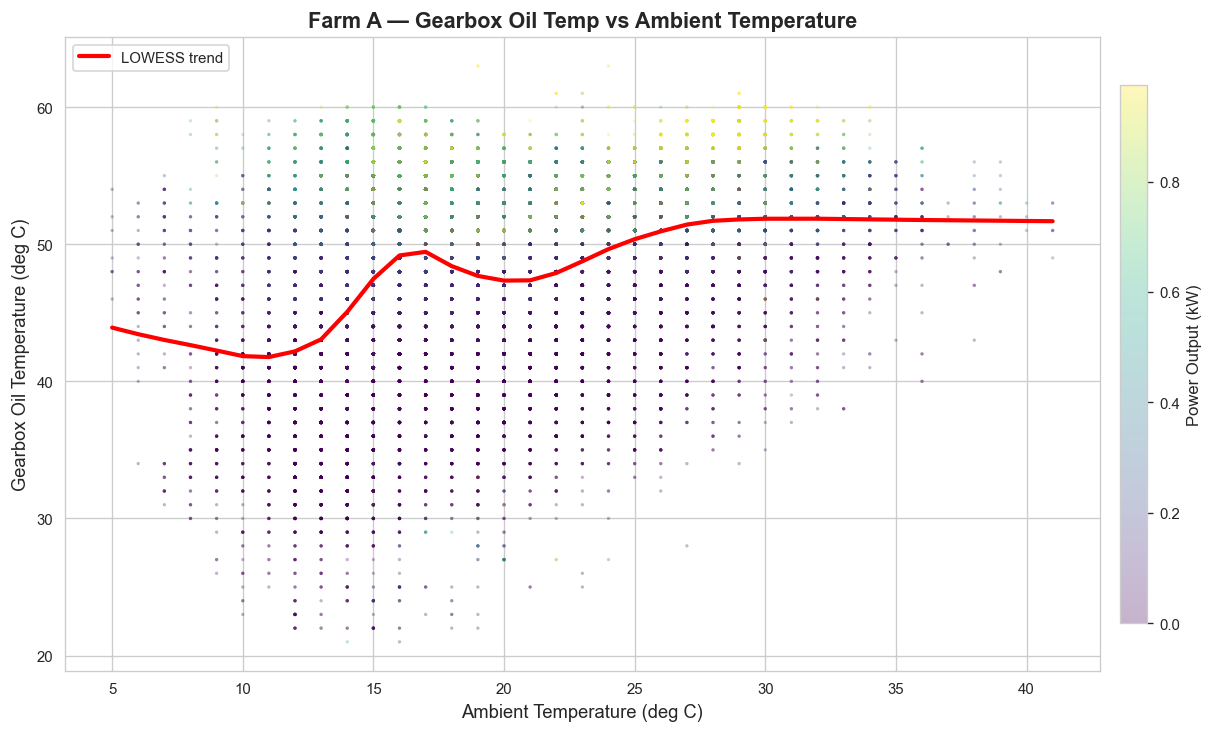

In [4]:
# --- Gearbox Oil Temp vs Ambient Temperature, colored by Power (Farm A) ---
temp_col = "sensor_12_avg"
amb_col = AMBIENT_COL["A"]
pw_col = POWER_COL["A"]

plot_df = df_a[[amb_col, pw_col, temp_col]].dropna()
if len(plot_df) > SAMPLE_N:
    plot_df = plot_df.sample(n=SAMPLE_N, random_state=42)

fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)

sc = ax.scatter(
    plot_df[amb_col], plot_df[temp_col],
    c=plot_df[pw_col], cmap="viridis", s=4, alpha=0.3,
    edgecolors="none", rasterized=True,
)
cb = fig.colorbar(sc, ax=ax, shrink=0.85, pad=0.02)
cb.set_label("Power Output (kW)", fontsize=10)

# LOWESS trend
sorted_idx = plot_df[amb_col].argsort()
lw = lowess(
    plot_df[temp_col].values[sorted_idx],
    plot_df[amb_col].values[sorted_idx],
    frac=0.2,
)
ax.plot(lw[:, 0], lw[:, 1], color="red", linewidth=2.5, label="LOWESS trend")

ax.set_xlabel("Ambient Temperature (deg C)")
ax.set_ylabel("Gearbox Oil Temperature (deg C)")
ax.set_title("Farm A — Gearbox Oil Temp vs Ambient Temperature",
             fontsize=13, fontweight="bold")
ax.legend(loc="upper left", fontsize=9)

fig.savefig(FIGURES_DIR / "temp_vs_ops_ambient_effect_farm_a.png", bbox_inches="tight", dpi=150)
print(f"Saved: temp_vs_ops_ambient_effect_farm_a.png")
plt.show()

## Cross-Farm: Same Relationship, Different Scales

Different farms use different turbine types with different power ratings and sensor calibrations. But the underlying physics is the same: more power output = more heat in the gearbox. If we see the same S-shaped temperature-vs-power relationship across all three farms, it validates that a single modeling approach (LightGBM NBM) can generalize across the fleet, even if the absolute temperature ranges differ.

Saved: temp_vs_ops_cross_farm_gearbox.png


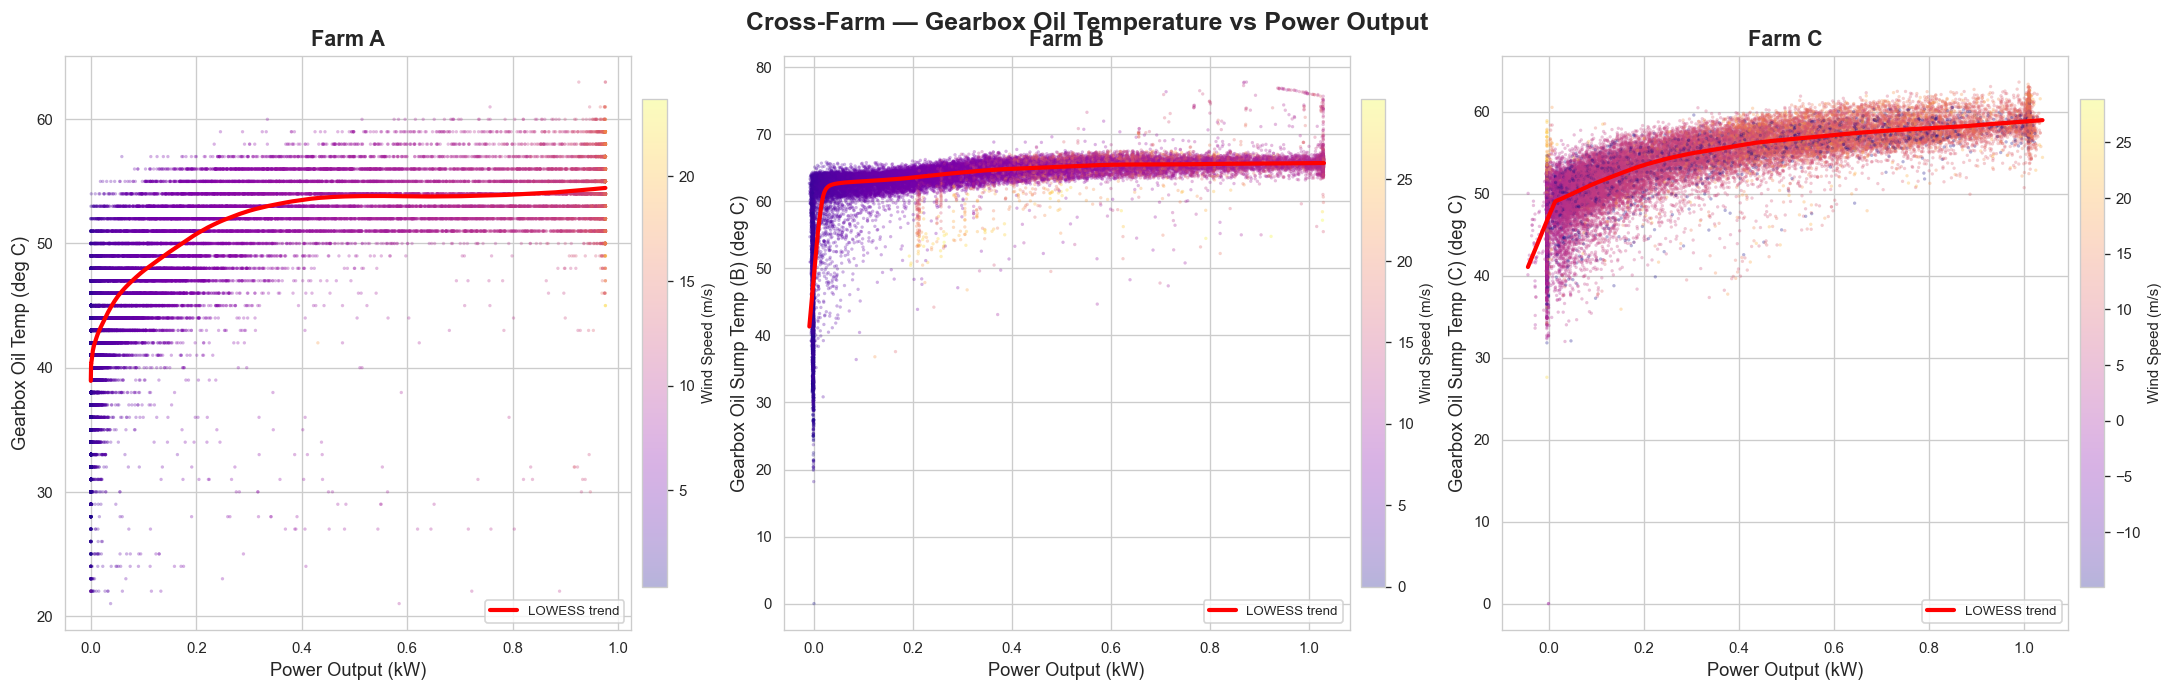

In [5]:
# --- Cross-Farm: Gearbox Oil Temp vs Power Output (A, B, C side by side) ---
farm_data = {"A": df_a, "B": df_b, "C": df_c}
farm_colors = {"A": "#2196F3", "B": "#FF9800", "C": "#4CAF50"}

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), constrained_layout=True)

for i, (farm_letter, df_farm) in enumerate(farm_data.items()):
    ax = axes[i]
    gb_col = GEARBOX_OIL_SENSOR[farm_letter]
    pw_col = POWER_COL[farm_letter]
    ws_col = WIND_COL[farm_letter]

    plot_df = df_farm[[pw_col, gb_col, ws_col]].dropna()
    if len(plot_df) > SAMPLE_N:
        plot_df = plot_df.sample(n=SAMPLE_N, random_state=42)

    sc = ax.scatter(
        plot_df[pw_col], plot_df[gb_col],
        c=plot_df[ws_col], cmap="plasma", s=4, alpha=0.3,
        edgecolors="none", rasterized=True,
    )
    cb = fig.colorbar(sc, ax=ax, shrink=0.85, pad=0.02)
    cb.set_label("Wind Speed (m/s)", fontsize=9)

    # LOWESS trend
    sorted_idx = plot_df[pw_col].argsort()
    lw = lowess(
        plot_df[gb_col].values[sorted_idx],
        plot_df[pw_col].values[sorted_idx],
        frac=0.15,
    )
    ax.plot(lw[:, 0], lw[:, 1], color="red", linewidth=2.5, label="LOWESS trend")

    sensor_label = SENSOR_LABELS.get(gb_col, gb_col)
    ax.set_xlabel("Power Output (kW)")
    ax.set_ylabel(f"{sensor_label} (deg C)")
    ax.set_title(f"Farm {farm_letter}", fontsize=13, fontweight="bold")
    ax.legend(loc="lower right", fontsize=8)

fig.suptitle("Cross-Farm — Gearbox Oil Temperature vs Power Output",
             fontsize=15, fontweight="bold", y=1.02)

fig.savefig(FIGURES_DIR / "temp_vs_ops_cross_farm_gearbox.png", bbox_inches="tight", dpi=150)
print(f"Saved: temp_vs_ops_cross_farm_gearbox.png")
plt.show()

## Correlation Between Operating Conditions and Temperatures

Before building NBMs, we want a quick summary of which operating conditions most influence which temperatures. A correlation heatmap (Pearson) across all operating condition features and all thermal sensors gives us a bird's-eye view.

**What to look for:**
- High positive correlation between power/wind speed and most thermal sensors (load-driven heating)
- Moderate positive correlation between ambient temperature and all component temperatures
- RPM may correlate differently depending on the turbine's control strategy

Saved: temp_vs_ops_correlation_heatmaps.png


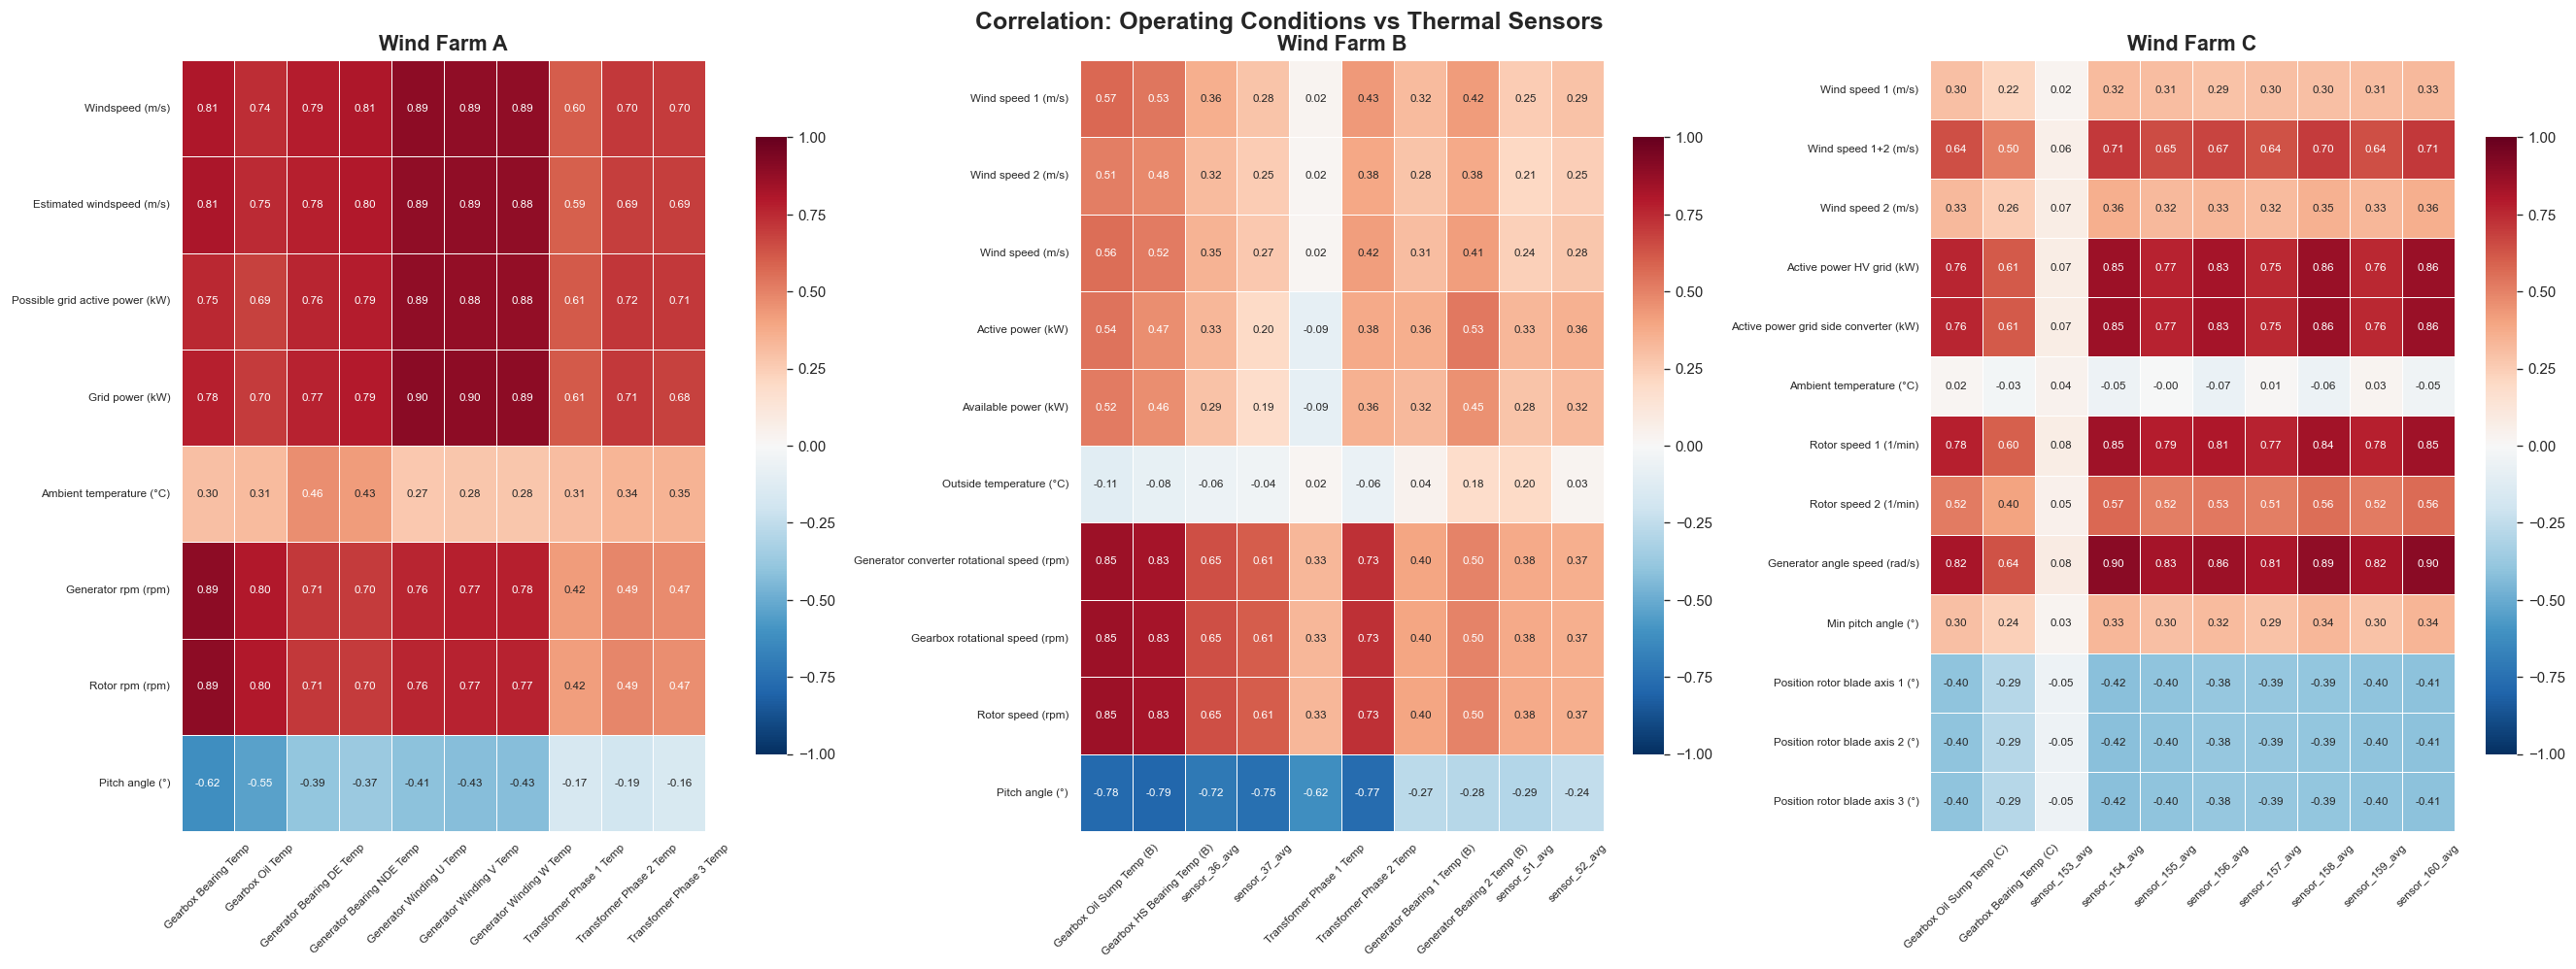

In [6]:
# --- Correlation heatmaps: Operating Conditions vs Thermal Sensors (per farm) ---

def make_corr_label(col, farm_name):
    """Return a short human-readable label for a column."""
    desc_map = FEATURE_DESCRIPTIONS.get(farm_name, {})
    if col in desc_map:
        name, unit = desc_map[col]
        return f"{name} ({unit})"
    if col in SENSOR_LABELS:
        return SENSOR_LABELS[col]
    return col


farm_configs = {
    "Wind Farm A": (df_a, "farm_a"),
    "Wind Farm B": (df_b, "farm_b"),
    "Wind Farm C": (df_c, "farm_c"),
}

fig, axes = plt.subplots(1, 3, figsize=(22, 8), constrained_layout=True)

for idx, (farm_name, (df_farm, farm_key)) in enumerate(farm_configs.items()):
    ax = axes[idx]

    op_cols = get_operating_features(farm_name)
    th_cols = get_all_thermal_sensors(farm_key)

    # Filter to columns that exist in the data
    op_cols = [c for c in op_cols if c in df_farm.columns]
    th_cols = [c for c in th_cols if c in df_farm.columns]

    # Limit thermal sensors for readability (pick up to 10)
    if len(th_cols) > 10:
        th_cols = th_cols[:10]

    # Compute correlation matrix between op features and thermal sensors
    combined = df_farm[op_cols + th_cols].dropna()
    corr = combined.corr().loc[op_cols, th_cols]

    # Human-readable labels
    y_labels = [make_corr_label(c, farm_name) for c in op_cols]
    x_labels = [SENSOR_LABELS.get(c, c) for c in th_cols]

    sns.heatmap(
        corr,
        ax=ax,
        xticklabels=x_labels,
        yticklabels=y_labels,
        cmap="RdBu_r",
        center=0,
        vmin=-1, vmax=1,
        annot=True,
        fmt=".2f",
        annot_kws={"size": 7},
        linewidths=0.5,
        cbar_kws={"shrink": 0.8},
    )

    ax.set_title(f"{farm_name}", fontsize=13, fontweight="bold")
    ax.tick_params(axis="x", rotation=45, labelsize=7)
    ax.tick_params(axis="y", rotation=0, labelsize=7)

fig.suptitle("Correlation: Operating Conditions vs Thermal Sensors",
             fontsize=15, fontweight="bold", y=1.02)

fig.savefig(FIGURES_DIR / "temp_vs_ops_correlation_heatmaps.png", bbox_inches="tight", dpi=150)
print(f"Saved: temp_vs_ops_correlation_heatmaps.png")
plt.show()

## R-squared Baseline: How Predictable Are Temperatures?

Before building complex models, a simple sanity check: **how much temperature variance can a plain linear regression explain using only operating condition features?**

If even a linear model achieves a high R-squared, it means the operating conditions contain strong signal — and a nonlinear model like LightGBM will do even better. This table gives us a floor for expected NBM performance and helps identify which sensors will be easy vs hard to model.

In [7]:
# --- R² Baseline: Linear Regression from Operating Conditions → Thermal Sensors ---
results = []

for farm_name, (df_farm, farm_key) in farm_configs.items():
    op_cols = get_operating_features(farm_name)
    op_cols = [c for c in op_cols if c in df_farm.columns]

    # Get all thermal sensors, but limit to first 10 for tractability
    th_cols = get_all_thermal_sensors(farm_key)
    th_cols = [c for c in th_cols if c in df_farm.columns]
    if len(th_cols) > 10:
        th_cols = th_cols[:10]

    for th_col in th_cols:
        subset = df_farm[op_cols + [th_col]].dropna()
        if len(subset) < 100:
            continue

        X = subset[op_cols].values
        y = subset[th_col].values

        lr = LinearRegression()
        lr.fit(X, y)
        r2 = lr.score(X, y)

        sensor_label = SENSOR_LABELS.get(th_col, th_col)
        results.append({
            "Farm": farm_name,
            "Target Sensor": sensor_label,
            "Column": th_col,
            "R² (Linear)": round(r2, 4),
            "N samples": len(subset),
        })

r2_df = pd.DataFrame(results)

# Display styled table
print("=" * 75)
print("  R² Baseline — Linear Regression: Operating Conditions → Temperature")
print("=" * 75)

for farm_name in ["Wind Farm A", "Wind Farm B", "Wind Farm C"]:
    farm_rows = r2_df[r2_df["Farm"] == farm_name].copy()
    farm_rows = farm_rows.sort_values("R² (Linear)", ascending=False)
    print(f"\n--- {farm_name} ---")
    print(farm_rows[["Target Sensor", "R² (Linear)", "N samples"]].to_string(index=False))

# Summary stats
mean_r2 = r2_df["R² (Linear)"].mean()
max_r2 = r2_df["R² (Linear)"].max()
min_r2 = r2_df["R² (Linear)"].min()
print(f"\nOverall: mean R² = {mean_r2:.4f}, max = {max_r2:.4f}, min = {min_r2:.4f}")
print(f"Even a simple linear model explains {mean_r2*100:.1f}% of temperature variance on average.")
print("A LightGBM NBM will capture the remaining nonlinear patterns.")

  R² Baseline — Linear Regression: Operating Conditions → Temperature

--- Wind Farm A ---
             Target Sensor  R² (Linear)  N samples
  Generator Winding U Temp       0.8779     464694
      Gearbox Bearing Temp       0.8772     464694
  Generator Winding V Temp       0.8760     464694
  Generator Winding W Temp       0.8725     464694
 Generator Bearing DE Temp       0.7748     464694
Generator Bearing NDE Temp       0.7725     464692
          Gearbox Oil Temp       0.7339     464694
  Transformer Phase 2 Temp       0.5816     464694
  Transformer Phase 3 Temp       0.5698     464694
  Transformer Phase 1 Temp       0.4380     464694

--- Wind Farm B ---
               Target Sensor  R² (Linear)  N samples
 Gearbox HS Bearing Temp (B)       0.7954     418792
   Gearbox Oil Sump Temp (B)       0.7914     418792
    Transformer Phase 2 Temp       0.6777     418792
               sensor_37_avg       0.6248     418792
               sensor_36_avg       0.5649     418792
    Trans

In [8]:
# --- Save summary of all figures produced by this notebook ---
print("=" * 60)
print("All figures saved to outputs/figures/:")
print("=" * 60)
for f in sorted(FIGURES_DIR.glob("temp_vs_ops_*.png")):
    size_kb = f.stat().st_size / 1024
    print(f"  {f.name:50s} ({size_kb:.0f} KB)")

All figures saved to outputs/figures/:
  temp_vs_ops_ambient_effect_farm_a.png              (130 KB)
  temp_vs_ops_correlation_heatmaps.png               (392 KB)
  temp_vs_ops_cross_farm_gearbox.png                 (513 KB)
  temp_vs_ops_gearbox_oil_farm_a.png                 (334 KB)
  temp_vs_ops_gen_bearing_farm_a.png                 (470 KB)


## Key Observations

**Temperature-Operating Condition Relationships:**
- Gearbox oil and generator bearing temperatures show clear, nonlinear relationships with both wind speed and power output
- The LOWESS trend lines confirm the expected S-shaped curve: temperature rises steeply through partial load, then flattens at rated power
- Color encoding reveals the 3-way interaction — at the same wind speed, higher power corresponds to higher temperatures

**Ambient Temperature Effect:**
- Strong positive correlation between ambient temperature and all component temperatures
- This confirms that ambient temp must be included as an NBM input to avoid false alarms on hot days
- The color gradient shows that load amplifies the ambient effect — high power + high ambient = hottest readings

**Cross-Farm Consistency:**
- All three farms show the same fundamental gearbox oil temp vs power relationship, despite different turbine types and scales
- The shape of the relationship is consistent; only the absolute temperature range and power rating differ
- This validates using a unified NBM architecture across the fleet (train per-farm, same approach)

**R-squared Baseline:**
- Linear regression from operating conditions alone explains a substantial portion of temperature variance
- This confirms that temperature is highly predictable from operating conditions — the core premise of NBM
- LightGBM will capture the remaining nonlinear patterns and interactions for even higher accuracy

**Implications for Phase 3 (Normal Behavior Models):**
- All operating condition features (wind speed, power, ambient temp, RPM, pitch) should be included as NBM inputs
- Gearbox and generator bearing sensors show the strongest operating-condition dependence — best candidates for high-quality NBMs
- Per-farm models are necessary due to different sensor scales, but the same feature set and architecture apply across farms